## Librerias

In [22]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import psycopg2
from pgvector.psycopg2 import register_vector
from sklearn.metrics import ndcg_score
import numpy as np
import os
import json
import uuid
import cv2
import matplotlib.pyplot as plt


## Instanciacion del modelo y preprocesamiento

In [23]:
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)

model.classifier[2] = torch.nn.Identity()   # remplaza la ultima capa por la identidad, devuelve vector de 768
model.eval()
preprocess = weights.transforms()

## Funcion para obtener embeddings

In [24]:
def obtener_embedding (image:np.ndarray) -> list[float]:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(image_rgb)
        image_tensor = preprocess(image_pil).unsqueeze(0)

        with torch.inference_mode():
            embedding = model(image_tensor).squeeze(0)

        return embedding.cpu().tolist()

## Conexion con la base de datos

In [25]:
conn = psycopg2.connect(
    dbname="dogs", 
    user="dogs_user", 
    password="dogs_pass", 
    host="localhost", 
    port="5432"
)
cur = conn.cursor()
cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
register_vector(conn)

cur.execute("""
    CREATE TABLE IF NOT EXISTS embeddings (
        id_imagen VARCHAR PRIMARY KEY,
        embedding vector(768),
        path VARCHAR NOT NULL,
        breed VARCHAR NOT NULL,
        metadata JSONB
    );
""")
conn.commit()

## Agregar los registros de train a la base

In [ ]:
def indexar_dataset(ruta_dataset):
    for raza in os.listdir(ruta_dataset):
        raza_path = os.path.join(ruta_dataset, raza)
            
        for img_name in os.listdir(raza_path):
            img_path = os.path.join(raza_path, img_name)
            
            image = cv2.imread(img_path)
            if image is None: 
                continue
                
            emb = obtener_embedding(image)
            img_id = str(uuid.uuid4())  
            
            cur.execute("""
                INSERT INTO embeddings (id_imagen, embedding, path, breed, metadata)
                VALUES (%s, %s, %s, %s, %s)
            """, (img_id, emb, img_path, raza, json.dumps({"source": "train"})))
    conn.commit()

# indexar_dataset("data/dataset/train")

## Busqueda por similitud

In [26]:
def buscar_similar(query_embedding, top_k=10, metric='cosine'):
    emb_str = str(query_embedding)
    
    if metric == 'cosine':
        query = """
            SELECT path, breed, 1 - (embedding <=> %s::vector) AS score
            FROM embeddings ORDER BY embedding <=> %s::vector LIMIT %s;
        """
    else:
        query = """
            SELECT path, breed, (embedding <-> %s::vector) AS score
            FROM embeddings ORDER BY embedding <-> %s::vector LIMIT %s;
        """
        
    cur.execute(query, (emb_str, emb_str, top_k))
    return cur.fetchall()

## Funcion para graficar las imagenes similares

In [27]:
def plot_similares(image: np.ndarray, top_k: int = 10, metric: str = 'cosine'):
    emb = obtener_embedding(image)
    
    resultados = buscar_similar(emb, top_k, metric)
    
    fig = plt.figure(figsize=(15, 5))
    
    ax_query = fig.add_subplot(2, 6, 1)
    ax_query.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax_query.set_title("Consulta", fontweight='bold')
    ax_query.axis("off")
    
    for i, (path, breed, score) in enumerate(resultados):
        img_res = cv2.imread(path)
        pos = i + 2 if i < 5 else i + 3
        
        ax_res = fig.add_subplot(2, 6, pos)
        if img_res is not None:
            ax_res.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
            
        ax_res.set_title(f"{breed}\nScore: {score:.3f}", fontsize=9)
        ax_res.axis("off")
        
    plt.tight_layout()
    plt.show()

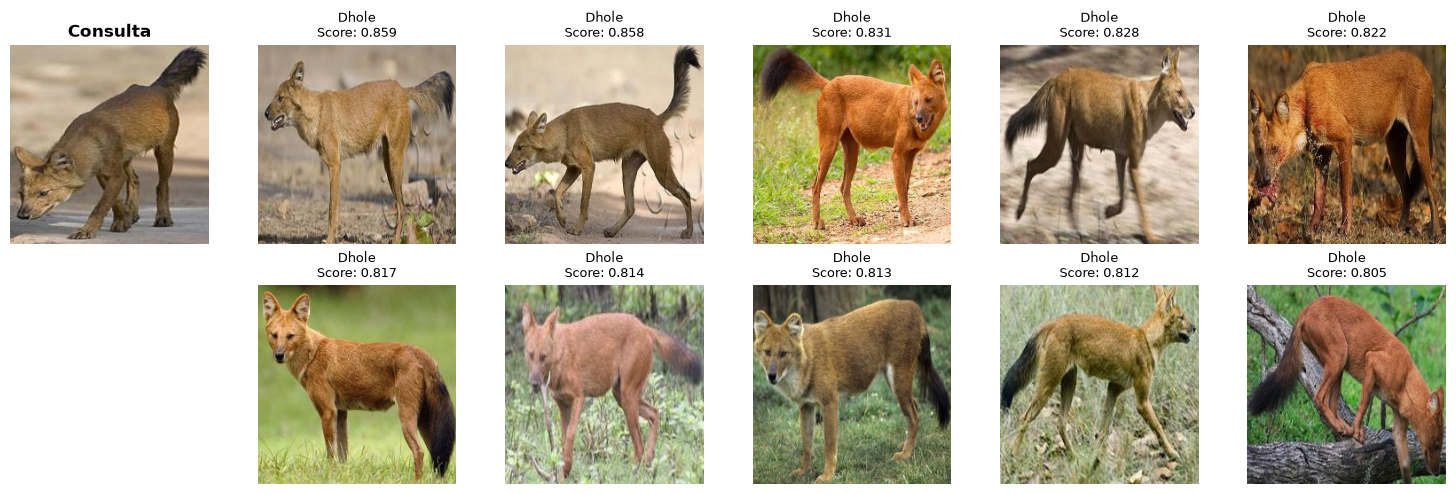

In [28]:
imagen_consulta = cv2.imread("data/dataset/test/Dhole/01.jpg")

if imagen_consulta is not None:
    plot_similares(imagen_consulta)
else:
    print("error")


In [8]:
# conn.rollback()

## Buscar por vecinos cercanos

In [ ]:
def predecir_raza_desde_vecinos(
    resultados: list[tuple[str, str, float]],
    similarity_threshold: float = 0.55,
    metric: str = "cosine",
) -> tuple[str, float]:
    """Predice la raza mediante voto ponderado por similitud.

    Cada resultado debe tener la forma (path, breed, score). Para L2,
    buscar_similar devuelve una distancia, por lo que se transforma a
    similitud con 1 / (1 + distancia) antes de realizar la votacion.
    """
    if not resultados:
        return "unknown", 0.0

    vecinos = []
    for path, breed, score in resultados:
        score = float(score)
        similitud = 1.0 / (1.0 + score) if metric.lower() == "l2" else score
        vecinos.append((path, breed, similitud))

    mejor_score = max(score for _, _, score in vecinos)
    if mejor_score < similarity_threshold:
        return "unknown", mejor_score

    votos = {}
    mejor_score_por_raza = {}
    for _, breed, score in vecinos:
        votos[breed] = votos.get(breed, 0.0) + score
        mejor_score_por_raza[breed] = max(
            mejor_score_por_raza.get(breed, float("-inf")),
            score,
        )

    raza_predicha = max(
        votos,
        key=lambda breed: (
            votos[breed],
            mejor_score_por_raza[breed],
            breed,
        ),
    )
    return raza_predicha, mejor_score_por_raza[raza_predicha]


def predecir_raza(
    image: np.ndarray,
    top_k: int = 10,
    metric: str = "cosine",
    similarity_threshold: float = 0.55,
):
    """Ejecuta el flujo embedding -> vecinos cercanos -> raza predicha."""
    embedding = obtener_embedding(image)
    resultados = buscar_similar(embedding, top_k=top_k, metric=metric)
    raza, score = predecir_raza_desde_vecinos(
        resultados,
        similarity_threshold=similarity_threshold,
        metric=metric,
    )
    return raza, score, resultados



if imagen_consulta is not None:
    raza_predicha, score_prediccion, vecinos = predecir_raza(imagen_consulta)
    print(f"Raza predicha: {raza_predicha}")
    print(f"Score: {score_prediccion:.4f}")
    print(f"Vecinos recuperados: {len(vecinos)}")


Raza predicha: Dhole
Score: 0.8590
Vecinos recuperados: 10


## Calculo de NDCG@10 por clase

In [ ]:
def calcular_ndcg_por_raza(k: int = 10, metric: str = 'cosine'):
    cur.execute("SELECT id_imagen, embedding, breed FROM dog_embeddings")
    dataset = cur.fetchall()
    
    operador = '<=>' if metric == 'cosine' else '<->'
    ndcg_por_raza = {}
    conteos_por_raza = {}
    
    for id_img, emb, raza_true in dataset:
        # Aseguramos que conserve las comas al pasarlo a texto
        emb_str = str(emb.tolist() if hasattr(emb, 'tolist') else list(emb))
        
        query = f"""
            SELECT breed FROM dog_embeddings
            WHERE id_imagen != %s
            ORDER BY embedding {operador} %s
            LIMIT %s
        """
        cur.execute(query, (id_img, emb_str, k))
        resultados = cur.fetchall()
        
        relevancias = [1 if res[0] == raza_true else 0 for res in resultados]
        dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(relevancias))
        idcg = sum(1 / np.log2(i + 2) for i in range(k))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        
        ndcg_por_raza[raza_true] = ndcg_por_raza.get(raza_true, 0.0) + ndcg
        conteos_por_raza[raza_true] = conteos_por_raza.get(raza_true, 0) + 1
        
    for raza in ndcg_por_raza:
        ndcg_por_raza[raza] /= conteos_por_raza[raza]
        
    return ndcg_por_raza


resultados_ndcg = calcular_ndcg_por_raza(k=10, metric='cosine')
for raza, score in resultados_ndcg.items():
    print(f"Raza: {raza} | NDCG@10: {score:.4f}")

Raza: Afghan | NDCG@10: 0.9926
Raza: African Wild Dog | NDCG@10: 0.9942
Raza: Airedale | NDCG@10: 0.9933
Raza: American Hairless | NDCG@10: 0.7375
Raza: American Spaniel | NDCG@10: 0.7733
Raza: Basenji | NDCG@10: 0.9791
Raza: Basset | NDCG@10: 0.9940
Raza: Beagle | NDCG@10: 0.9695
Raza: Bearded Collie | NDCG@10: 0.9572
Raza: Bermaise | NDCG@10: 1.0000
Raza: Bichon Frise | NDCG@10: 0.9184
Raza: Blenheim | NDCG@10: 0.9430
Raza: Bloodhound | NDCG@10: 0.9943
Raza: Bluetick | NDCG@10: 0.9874
Raza: Border Collie | NDCG@10: 0.8334
Raza: Borzoi | NDCG@10: 0.9847
Raza: Boston Terrier | NDCG@10: 0.7456
Raza: Boxer | NDCG@10: 0.9639
Raza: Bull Mastiff | NDCG@10: 0.9242
Raza: Bull Terrier | NDCG@10: 0.8942
Raza: Bulldog | NDCG@10: 0.7441
Raza: Cairn | NDCG@10: 0.9642
Raza: Chihuahua | NDCG@10: 0.9681
Raza: Chinese Crested | NDCG@10: 0.8754
Raza: Chow | NDCG@10: 1.0000
Raza: Clumber | NDCG@10: 0.9871
Raza: Cockapoo | NDCG@10: 0.7841
Raza: Cocker | NDCG@10: 0.9412
Raza: Collie | NDCG@10: 0.9123
Raza